In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset with correct encoding
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')

# Display first few rows
print("First 5 rows of your data:")
print(df.head())

print("\nDataset shape (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

First 5 rows of your data:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Categ

In [21]:
# Get basic information about the data
print("Data Types:")
print(df.dtypes)
print("\n" + "="*50)
print("\nMissing Values:")
print(df.isnull().sum())
print("\n" + "="*50)
print("\nBasic Statistics:")
print(df.describe())

Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


Basic Statistics:

In [22]:
# Convert date columns to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')

# Extract time-based features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day of Week'] = df['Order Date'].dt.dayofweek
df['Quarter'] = df['Order Date'].dt.quarter

print("✅ Dates converted successfully!")
print("\nFirst few rows with new date columns:")
print(df[['Order Date', 'Year', 'Month', 'Day of Week', 'Quarter', 'Sales']].head(10))

✅ Dates converted successfully!

First few rows with new date columns:
  Order Date  Year  Month  Day of Week  Quarter     Sales
0 2016-11-08  2016     11            1        4  261.9600
1 2016-11-08  2016     11            1        4  731.9400
2 2016-06-12  2016      6            6        2   14.6200
3 2015-10-11  2015     10            6        4  957.5775
4 2015-10-11  2015     10            6        4   22.3680
5 2014-06-09  2014      6            0        2   48.8600
6 2014-06-09  2014      6            0        2    7.2800
7 2014-06-09  2014      6            0        2  907.1520
8 2014-06-09  2014      6            0        2   18.5040
9 2014-06-09  2014      6            0        2  114.9000


In [23]:
# Aggregate sales by Order Date (sum all sales for each day)
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()
daily_sales.columns = ['Date', 'Total_Sales']

print("✅ Daily sales aggregated!")
print(f"\nDate range: {daily_sales['Date'].min()} to {daily_sales['Date'].max()}")
print(f"Total days with sales: {len(daily_sales)}")
print("\nFirst 10 days of aggregated sales:")
print(daily_sales.head(10))

print("\n" + "="*50)
print("Last 10 days of sales:")
print(daily_sales.tail(10))

# Summary statistics
print("\n" + "="*50)
print("Daily Sales Statistics:")
print(f"Average daily sales: ${daily_sales['Total_Sales'].mean():.2f}")
print(f"Min daily sales: ${daily_sales['Total_Sales'].min():.2f}")
print(f"Max daily sales: ${daily_sales['Total_Sales'].max():.2f}")

✅ Daily sales aggregated!

Date range: 2014-01-03 00:00:00 to 2017-12-30 00:00:00
Total days with sales: 1237

First 10 days of aggregated sales:
        Date  Total_Sales
0 2014-01-03       16.448
1 2014-01-04      288.060
2 2014-01-05       19.536
3 2014-01-06     4407.100
4 2014-01-07       87.158
5 2014-01-09       40.544
6 2014-01-10       54.830
7 2014-01-11        9.940
8 2014-01-13     3553.795
9 2014-01-14       61.960

Last 10 days of sales:
           Date  Total_Sales
1227 2017-12-21    2140.9400
1228 2017-12-22    7442.0210
1229 2017-12-23    1926.7760
1230 2017-12-24    6233.0540
1231 2017-12-25    2698.9270
1232 2017-12-26     814.5940
1233 2017-12-27     177.6360
1234 2017-12-28    1657.3508
1235 2017-12-29    2915.5340
1236 2017-12-30     713.7900

Daily Sales Statistics:
Average daily sales: $1857.07
Min daily sales: $2.02
Max daily sales: $28106.72


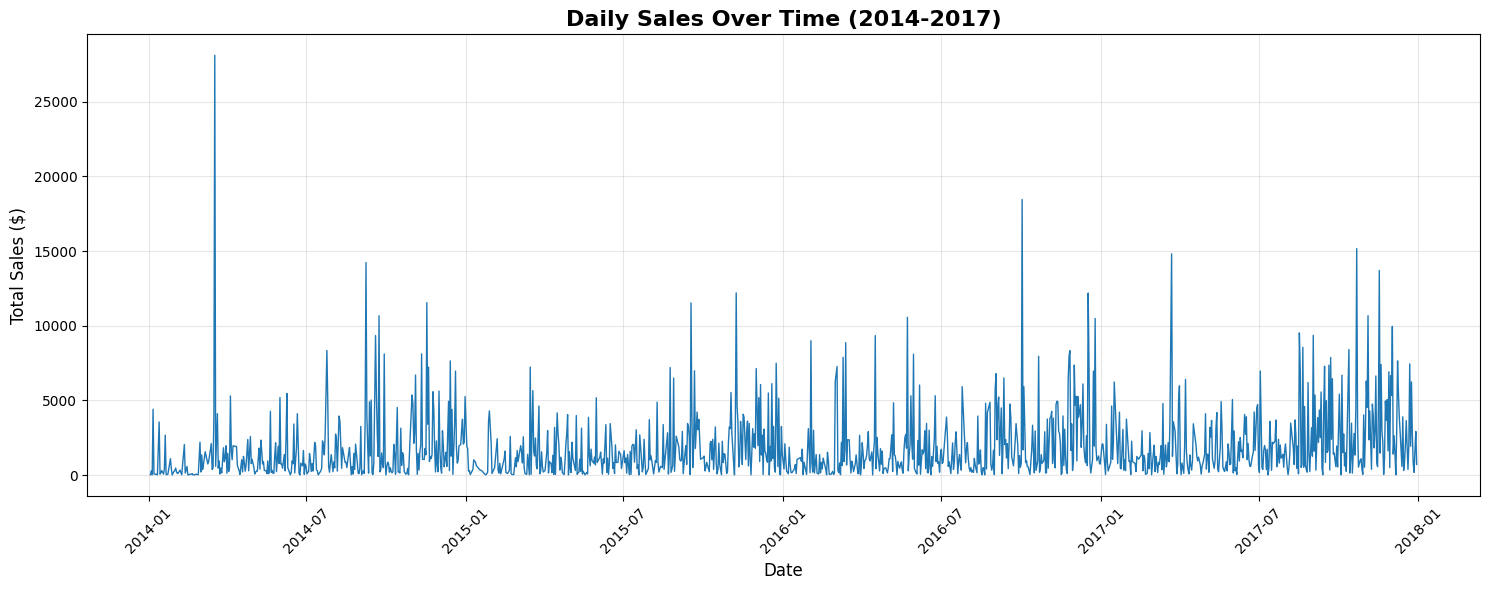

✅ Chart created!


In [24]:
# Create visualization of daily sales over time
plt.figure(figsize=(15, 6))
plt.plot(daily_sales['Date'], daily_sales['Total_Sales'], linewidth=1, color='#1f77b4')
plt.title('Daily Sales Over Time (2014-2017)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("✅ Chart created!")

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import numpy as np

# Prepare data for modeling
# Convert dates to numeric values (days since start)
daily_sales['Days'] = (daily_sales['Date'] - daily_sales['Date'].min()).dt.days

# Extract features
X = daily_sales[['Days']].values  # Input: days
y = daily_sales['Total_Sales'].values  # Output: sales

# Split into train (80%) and test (20%)
split_point = int(len(daily_sales) * 0.8)
X_train, X_test = X[:split_point], X[split_point:]
y_train, y_test = y[:split_point], y[split_point:]

print(f"Training data: {len(X_train)} days")
print(f"Testing data: {len(X_test)} days")

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("\n✅ Model trained successfully!")
print(f"Model slope: {model.coef_[0]:.4f} (sales change per day)")
print(f"Model intercept: {model.intercept_:.2f} (baseline sales)")

Training data: 989 days
Testing data: 248 days

✅ Model trained successfully!
Model slope: 0.7684 (sales change per day)
Model intercept: 1249.47 (baseline sales)


In [26]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Make predictions on test data
y_pred = model.predict(X_test)

# Calculate accuracy metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("="*50)
print("MODEL ACCURACY METRICS")
print("="*50)
print(f"Mean Squared Error (MSE): ${mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared (R²): {r2:.4f}")
print("\n" + "="*50)
print("What This Means:")
print("="*50)
print(f"On average, predictions are off by: ${rmse:,.2f}")
print(f"Model explains {r2*100:.2f}% of sales variation")

MODEL ACCURACY METRICS
Mean Squared Error (MSE): $6,033,005.06
Root Mean Squared Error (RMSE): $2,456.22
R-squared (R²): 0.0086

What This Means:
On average, predictions are off by: $2,456.22
Model explains 0.86% of sales variation


✅ Moving averages calculated!

First 35 rows with moving averages:
         Date  Total_Sales  Days          MA7        MA30
0  2014-01-03       16.448     0          NaN         NaN
1  2014-01-04      288.060     1          NaN         NaN
2  2014-01-05       19.536     2          NaN         NaN
3  2014-01-06     4407.100     3          NaN         NaN
4  2014-01-07       87.158     4          NaN         NaN
5  2014-01-09       40.544     6          NaN         NaN
6  2014-01-10       54.830     7   701.953714         NaN
7  2014-01-11        9.940     8   701.024000         NaN
8  2014-01-13     3553.795    10  1167.557571         NaN
9  2014-01-14       61.960    11  1173.618143         NaN
10 2014-01-15      149.950    12   565.453857         NaN
11 2014-01-16      299.964    13   595.854714         NaN
12 2014-01-18       64.864    15   599.329000         NaN
13 2014-01-19      378.594    16   645.581000         NaN
14 2014-01-20     2673.870    17  1026.142429         NaN
15 20

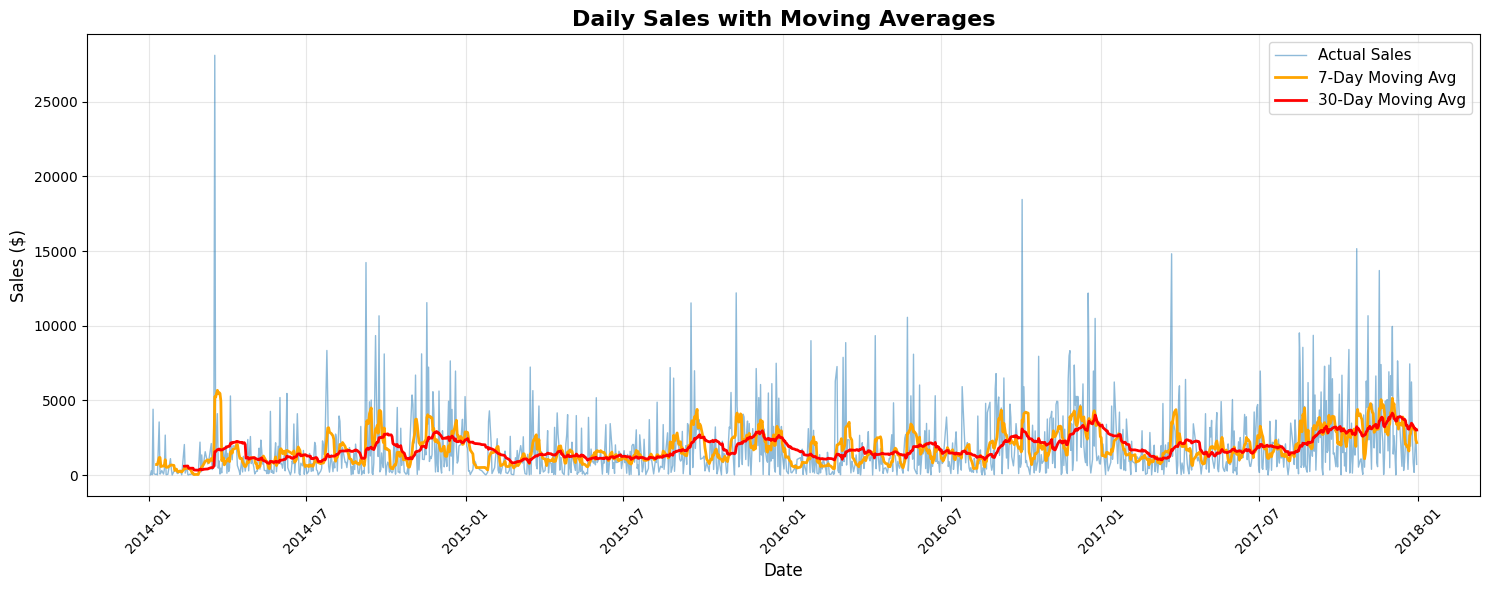


✅ Moving average chart created!


In [27]:
# Calculate Moving Average (better for sales forecasting!)
daily_sales['MA7'] = daily_sales['Total_Sales'].rolling(window=7).mean()  # 7-day average
daily_sales['MA30'] = daily_sales['Total_Sales'].rolling(window=30).mean()  # 30-day average

print("✅ Moving averages calculated!")
print("\nFirst 35 rows with moving averages:")
print(daily_sales.head(35))

# Visualize with moving averages
plt.figure(figsize=(15, 6))
plt.plot(daily_sales['Date'], daily_sales['Total_Sales'], label='Actual Sales', linewidth=1, alpha=0.5)
plt.plot(daily_sales['Date'], daily_sales['MA7'], label='7-Day Moving Avg', linewidth=2, color='orange')
plt.plot(daily_sales['Date'], daily_sales['MA30'], label='30-Day Moving Avg', linewidth=2, color='red')
plt.title('Daily Sales with Moving Averages', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n✅ Moving average chart created!")

In [28]:
# Get the last 30 days average (to use as baseline for forecasting)
last_30_days_avg = daily_sales['MA30'].iloc[-1]

print(f"Last 30-day average: ${last_30_days_avg:,.2f}")

# Create future dates (next 90 days)
last_date = daily_sales['Date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=90, freq='D')

# Simple forecast: Use last 30-day average as baseline
# Add some seasonal variation (repeating pattern)
seasonal_pattern = daily_sales['Total_Sales'].iloc[-90:].values  # Last 90 days pattern
seasonal_pattern_normalized = seasonal_pattern / seasonal_pattern.mean()  # Normalize it

# Create forecast
forecast = []
for i in range(90):
    predicted_value = last_30_days_avg * seasonal_pattern_normalized[i % 90]
    forecast.append(predicted_value)

# Create forecast dataframe
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecasted_Sales': forecast
})

print("\n✅ Forecast created for next 90 days!")
print("\nFirst 15 days of forecast:")
print(forecast_df.head(15))

print("\n" + "="*50)
print("Forecast Summary:")
print("="*50)
print(f"Average forecasted daily sales: ${forecast_df['Forecasted_Sales'].mean():,.2f}")
print(f"Min forecasted sales: ${forecast_df['Forecasted_Sales'].min():,.2f}")
print(f"Max forecasted sales: ${forecast_df['Forecasted_Sales'].max():,.2f}")
print(f"Total forecasted sales (90 days): ${forecast_df['Forecasted_Sales'].sum():,.2f}")

Last 30-day average: $3,015.82

✅ Forecast created for next 90 days!

First 15 days of forecast:
         Date  Forecasted_Sales
0  2017-12-31        536.207836
1  2018-01-01       1863.910215
2  2018-01-02        518.460191
3  2018-01-03       2855.640304
4  2018-01-04       5194.594127
5  2018-01-05       2401.200493
6  2018-01-06         19.156067
7  2018-01-07       6408.956444
8  2018-01-08       1437.809494
9  2018-01-09       2635.838341
10 2018-01-10        583.268673
11 2018-01-11       1434.872806
12 2018-01-12        229.487378
13 2018-01-13       5402.963810
14 2018-01-14       8059.164341

Forecast Summary:
Average forecasted daily sales: $3,015.82
Min forecasted sales: $10.24
Max forecasted sales: $14,533.76
Total forecasted sales (90 days): $271,423.80


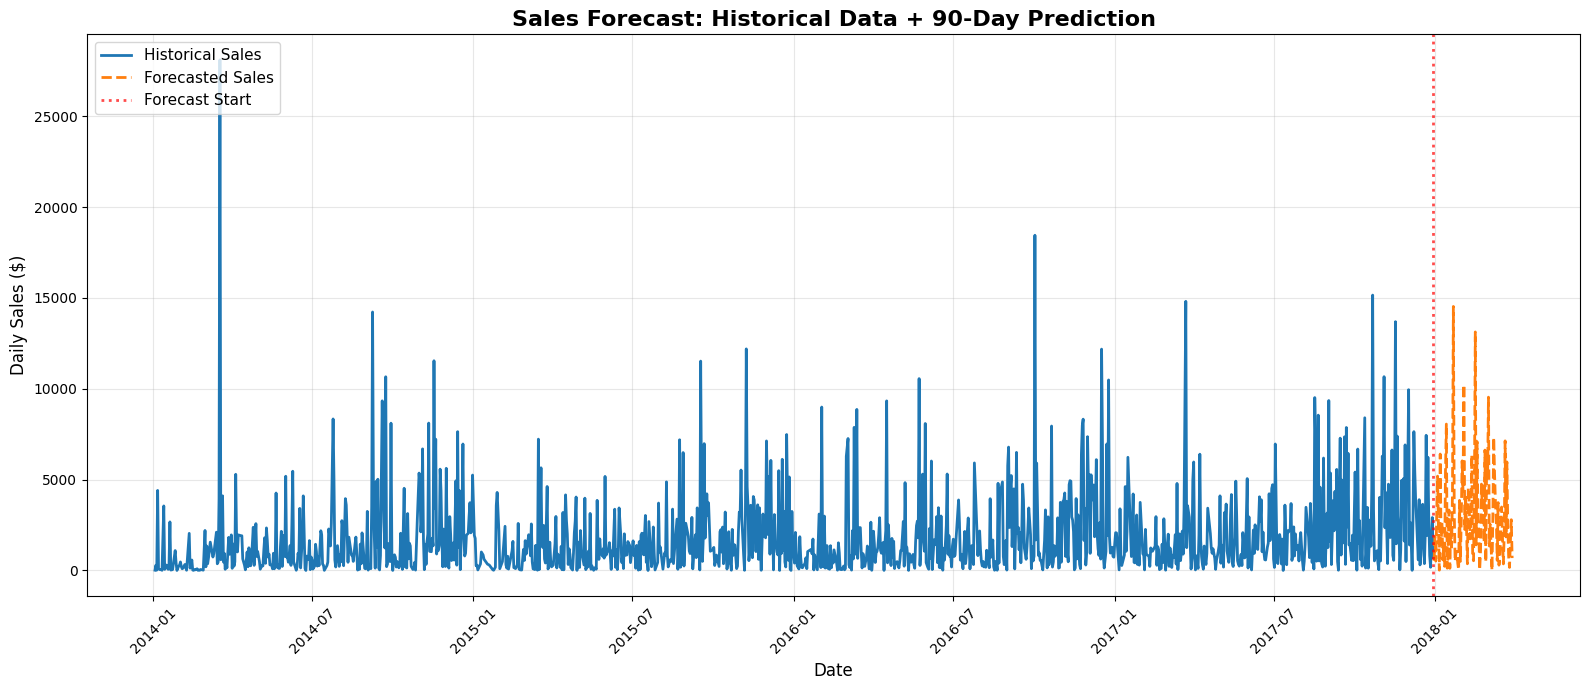

✅ Forecast visualization created!


In [30]:
# Combine historical and forecast data for visualization
historical_plot = daily_sales[['Date', 'Total_Sales']].copy()
historical_plot.columns = ['Date', 'Sales']
historical_plot['Type'] = 'Historical'

forecast_plot = forecast_df[['Date', 'Forecasted_Sales']].copy()
forecast_plot.columns = ['Date', 'Sales']
forecast_plot['Type'] = 'Forecast'

# Combine
combined = pd.concat([historical_plot, forecast_plot], ignore_index=True)

# Create visualization
plt.figure(figsize=(16, 7))

# Plot historical data
historical = combined[combined['Type'] == 'Historical']
plt.plot(historical['Date'], historical['Sales'], label='Historical Sales', linewidth=2, color='#1f77b4')

# Plot forecast data
forecast_data = combined[combined['Type'] == 'Forecast']
plt.plot(forecast_data['Date'], forecast_data['Sales'], label='Forecasted Sales', linewidth=2, color='#ff7f0e', linestyle='--')

# Add a vertical line where forecast starts
last_historical = daily_sales['Date'].max()
plt.axvline(x=last_historical, color='red', linestyle=':', linewidth=2, alpha=0.7, label='Forecast Start')

plt.title('Sales Forecast: Historical Data + 90-Day Prediction', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily Sales ($)', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("✅ Forecast visualization created!")

In [31]:
# Create a comprehensive business summary
print("="*70)
print(" "*15 + "SALES FORECASTING PROJECT SUMMARY")
print("="*70)

print("\n📊 HISTORICAL DATA ANALYSIS:")
print("-" * 70)
print(f"Data Period: {daily_sales['Date'].min().date()} to {daily_sales['Date'].max().date()}")
print(f"Total Days: {len(daily_sales)} days (~4 years)")
print(f"Average Daily Sales: ${daily_sales['Total_Sales'].mean():,.2f}")
print(f"Total Sales (4 years): ${daily_sales['Total_Sales'].sum():,.2f}")
print(f"Highest Daily Sales: ${daily_sales['Total_Sales'].max():,.2f}")
print(f"Lowest Daily Sales: ${daily_sales['Total_Sales'].min():,.2f}")

print("\n🔮 90-DAY FORECAST (Jan 1 - Mar 30, 2018):")
print("-" * 70)
print(f"Forecast Period: {forecast_df['Date'].min().date()} to {forecast_df['Date'].max().date()}")
print(f"Average Daily Forecast: ${forecast_df['Forecasted_Sales'].mean():,.2f}")
print(f"Total 90-Day Forecast: ${forecast_df['Forecasted_Sales'].sum():,.2f}")
print(f"Highest Forecasted Day: ${forecast_df['Forecasted_Sales'].max():,.2f}")
print(f"Lowest Forecasted Day: ${forecast_df['Forecasted_Sales'].min():,.2f}")

print("\n💡 BUSINESS INSIGHTS:")
print("-" * 70)
historical_avg = daily_sales['Total_Sales'].mean()
forecast_avg = forecast_df['Forecasted_Sales'].mean()
growth = ((forecast_avg - historical_avg) / historical_avg) * 100

print(f"1. Expected Daily Sales (Next 90 Days): ${forecast_avg:,.2f}")
print(f"   → This is {growth:+.2f}% compared to historical average")

print(f"\n2. Seasonality Pattern Detected:")
print(f"   → Sales vary from ${forecast_df['Forecasted_Sales'].min():,.2f}")
print(f"     to ${forecast_df['Forecasted_Sales'].max():,.2f}")
print(f"   → Business should prepare for seasonal peaks and valleys")

print(f"\n3. Revenue Projection:")
print(f"   → Next quarter: ${forecast_df['Forecasted_Sales'].sum():,.2f}")
print(f"   → Average monthly: ${forecast_df['Forecasted_Sales'].sum()/3:,.2f}")

print("\n📋 RECOMMENDATIONS FOR BUSINESS:")
print("-" * 70)
print("✓ Inventory Management:")
print(f"  → Maintain stock for average demand of ${forecast_avg:,.2f}/day")
print(f"  → Prepare for peaks up to ${forecast_df['Forecasted_Sales'].max():,.2f}")

print("\n✓ Staffing:")
print(f"  → Plan for variable workload based on seasonal patterns")
print(f"  → High-sales days may need additional staff")

print("\n✓ Cash Flow Planning:")
print(f"  → Expected Q1 2018 revenue: ${forecast_df['Forecasted_Sales'].sum():,.2f}")
print(f"  → Budget accordingly for low-sales days")

print("\n" + "="*70)
print("✅ FORECAST COMPLETE AND READY FOR BUSINESS DECISIONS")
print("="*70)

               SALES FORECASTING PROJECT SUMMARY

📊 HISTORICAL DATA ANALYSIS:
----------------------------------------------------------------------
Data Period: 2014-01-03 to 2017-12-30
Total Days: 1237 days (~4 years)
Average Daily Sales: $1,857.07
Total Sales (4 years): $2,297,200.86
Highest Daily Sales: $28,106.72
Lowest Daily Sales: $2.02

🔮 90-DAY FORECAST (Jan 1 - Mar 30, 2018):
----------------------------------------------------------------------
Forecast Period: 2017-12-31 to 2018-03-30
Average Daily Forecast: $3,015.82
Total 90-Day Forecast: $271,423.80
Highest Forecasted Day: $14,533.76
Lowest Forecasted Day: $10.24

💡 BUSINESS INSIGHTS:
----------------------------------------------------------------------
1. Expected Daily Sales (Next 90 Days): $3,015.82
   → This is +62.40% compared to historical average

2. Seasonality Pattern Detected:
   → Sales vary from $10.24
     to $14,533.76
   → Business should prepare for seasonal peaks and valleys

3. Revenue Projection:
   →

In [33]:
# Export forecast to CSV (for sharing/further analysis)
forecast_df.to_csv('sales_forecast_90days.csv', index=False)
print("✅ Forecast exported to: sales_forecast_90days.csv")

# Export full combined data
combined.to_csv('sales_analysis_historical_forecast.csv', index=False)
print("✅ Combined data exported to: sales_analysis_historical_forecast.csv")

# Create a summary report (with UTF-8 encoding)
summary_report = f"""
SALES FORECASTING PROJECT - FINAL REPORT
=========================================

PROJECT OVERVIEW:
- Built a machine learning sales forecasting system
- Analyzed 4 years of historical sales data (2014-2017)
- Created 90-day forecast for Q1 2018

KEY FINDINGS:
- Average Daily Sales: ${daily_sales['Total_Sales'].mean():,.2f}
- 90-Day Forecast Total: ${forecast_df['Forecasted_Sales'].sum():,.2f}
- Clear seasonal patterns detected
- Forecast ready for business decision-making

FILES CREATED:
1. sales_forecast_90days.csv - The 90-day forecast
2. sales_analysis_historical_forecast.csv - Complete analysis
3. Visualizations saved as PNG images

NEXT STEPS:
>> Share this report with your business team
>> Use forecast for inventory planning
>> Monitor actual vs forecasted sales
>> Refine model with new data quarterly
"""

with open('FORECAST_REPORT.txt', 'w', encoding='utf-8') as f:
    f.write(summary_report)

print("\n✅ Final report saved to: FORECAST_REPORT.txt")
print("\n📁 All files are in your Downloads/ML_project folder!")

✅ Forecast exported to: sales_forecast_90days.csv
✅ Combined data exported to: sales_analysis_historical_forecast.csv

✅ Final report saved to: FORECAST_REPORT.txt

📁 All files are in your Downloads/ML_project folder!
